In [17]:
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import trange
import numpy as np   

In [5]:
ds = xr.open_zarr('/home/NAS/homes/isaac-10009/Data/_silver_data/IMERG_V07/Early/2023_01.zarr')
ds

<xarray.Dataset> Size: 424GB
Dimensions:                         (time: 1488, lon: 3600, lat: 1800, latv: 2,
                                     lonv: 2, nv: 2)
Coordinates:
  * lat                             (lat) float32 7kB -89.95 -89.85 ... 89.95
  * latv                            (latv) int32 8B 0 1
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lonv                            (lonv) int32 8B 0 1
  * nv                              (nv) int32 8B 0 1
  * time                            (time) datetime64[ns] 12kB 2023-01-01 ......
Data variables: (12/13)
    IRinfluence                     (time, lon, lat) float32 39GB dask.array<chunksize=(24, 3600, 1800), meta=np.ndarray>
    IRprecipitation                 (time, lon, lat) float32 39GB dask.array<chunksize=(24, 3600, 1800), meta=np.ndarray>
    MWobservationTime               (time, lon, lat) timedelta64[ns] 77GB dask.array<chunksize=(24, 3600, 1800), meta=np.ndarray>
    MWprecipSource                  (time, lon, lat) float32 39GB dask.array<chunksize=(24, 3600, 1800), meta=np.ndarray>
    MWprecipitation                 (time, lon, lat) float32 39GB dask.array<chunksize=(24, 3600, 1800), meta=np.ndarray>
    lat_bnds                        (time, lat, latv) float32 21MB dask.array<chunksize=(1, 1800, 2), meta=np.ndarray>
    ...                              ...
    precipitation                   (time, lon, lat) float32 39GB dask.array<chunksize=(24, 3600, 1800), meta=np.ndarray>
    precipitationQualityIndex       (time, lon, lat) float32 39GB dask.array<chunksize=(24, 3600, 1800), meta=np.ndarray>
    precipitationUncal              (time, lon, lat) float32 39GB dask.array<chunksize=(24, 3600, 1800), meta=np.ndarray>
    probabilityLiquidPrecipitation  (time, lon, lat) float32 39GB dask.array<chunksize=(24, 3600, 1800), meta=np.ndarray>
    randomError                     (time, lon, lat) float32 39GB dask.array<chunksize=(24, 3600, 1800), meta=np.ndarray>
    time_bnds                       (time, nv) object 24kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    FileHeader:                      DOI=10.5067/GPM/IMERG/3B-HH-E/07;\nDOIau...
    FileInfo:                        DataFormatVersion=7e;\nTKCodeBuildVersio...
    Grid.GridHeader:                 BinMethod=ARITHMETIC_MEAN;\nRegistration...
    Grid.fullnamepath:               /Grid
    DODS_EXTRA.Unlimited_Dimension:  time
    history:                         2024-12-04 09:40:39 GMT Hyrax-1.16.3 htt...

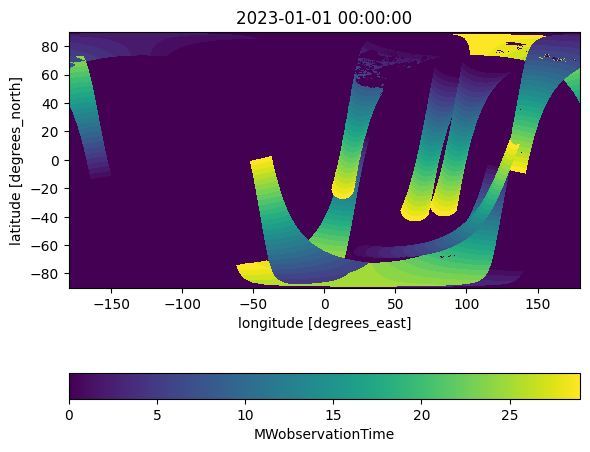

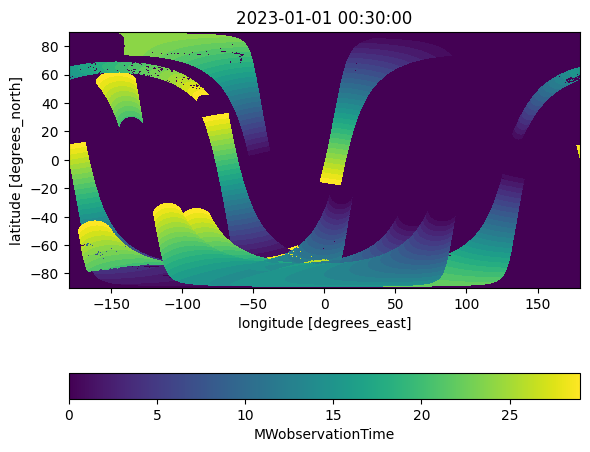

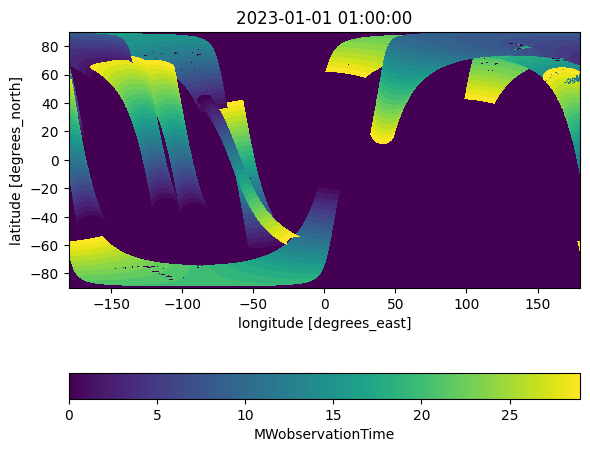

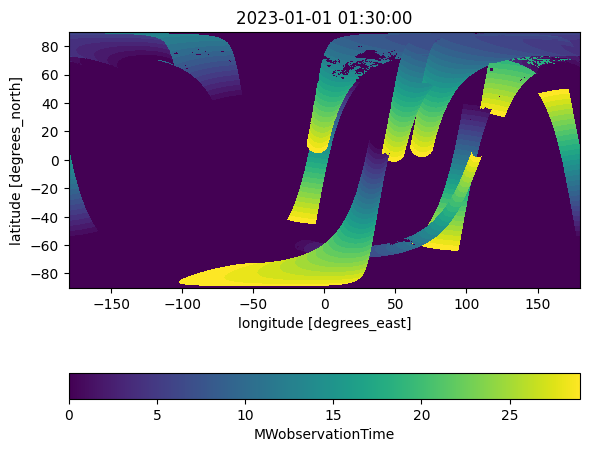

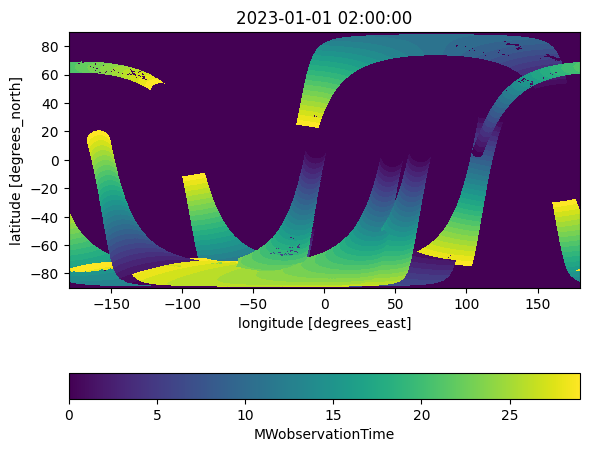

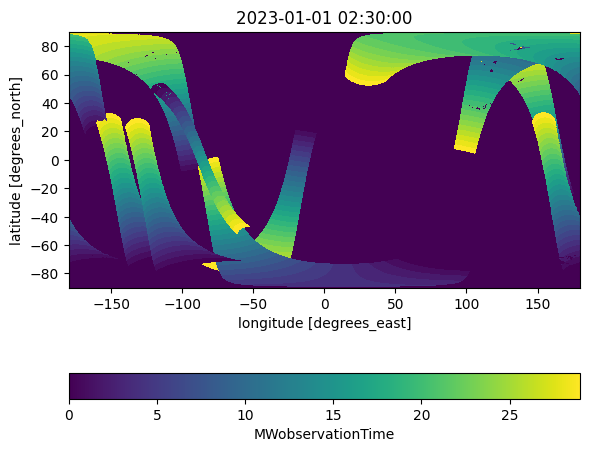

In [ ]:


for i in range(6):
    fig, ax = plt.subplots(1, 1, figsize = (6, 6), dpi = 100)
    da = ds.isel(time = i).MWobservationTime.astype(float) / 1e9 / 60
    da = da.where(da >= 0, 0)
    da.plot(x = 'lon', y = 'lat', ax = ax, cbar_kwargs = {"orientation": "horizontal"})
    ax.set_title(ds.isel(time = i).time.dt.strftime('%Y-%m-%d %H:%M:%S').values)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()